In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

## Load env

In [2]:
load_dotenv()  # Load environment variables from .env file

True

## Initialise the AI provider object

In [3]:
openaiobj= ChatOpenAI(model_name="gpt-4", temperature=0.5, max_tokens=1000)

## Create State

In [4]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeState) -> JokeState:
    # Generate a joke based on the topic
    joke_prompt = f"Generate a joke about {state['topic']}."
    joke_response = openaiobj.invoke(joke_prompt)
    state['joke'] = joke_response.content
    return {'joke':state['joke']}

In [6]:
def joke_explanation(state: JokeState) -> JokeState:
    # Generate an explanation for the joke
    explanation_prompt = f"Explain the following joke: {state['joke']}"
    explanation_response = openaiobj.invoke(explanation_prompt)
    state['explanation'] = explanation_response.content
    return {'explanation':state['explanation']}

## Join the nodes, create workflows

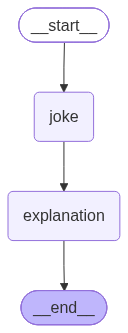

In [7]:
checkpointer = InMemorySaver()
graph= StateGraph(JokeState)

graph.add_node('joke', generate_joke)
graph.add_node('explanation', joke_explanation)

graph.add_edge(START, 'joke')
graph.add_edge('joke', 'explanation')
graph.add_edge('explanation', END)

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [8]:
config={"configurable": {"thread_id": "1"}}
workflow.invoke({'topic': 'programming'}, config=config)

{'topic': 'programming',
 'joke': "Why don't programmers like nature?\n\nBecause it has too many bugs.",
 'explanation': 'In programming, a "bug" is a term used to describe an error or flaw in the code that causes it to produce incorrect or unexpected results. The joke is a play on words: in nature, "bugs" refers to insects, while in programming, "bugs" refers to errors in code. The humor comes from the double meaning of the word "bugs". So, programmers don\'t like nature because it has too many "bugs" (insects), but also because they don\'t like "bugs" (errors) in their code.'}

In [ ]:
# workflow.invoke({'topic': 'Data Engineer'}, config=config)

{'topic': 'Data Engineer',
 'joke': "Why don't data engineers ever get locked out of their house?\n\nBecause they always have the keys... and the indexes, and the partitions!",
 'explanation': 'This joke is a play on the terminology used in data engineering. In the context of databases, keys, indexes, and partitions are all tools that data engineers use to organize and access data efficiently. The joke is that data engineers always have these tools, just like they would always have their house keys. The humor comes from the unexpected blending of two different contexts: data engineering and home security.'}

### Here's some typical functions showed to understand

#### 1. get_state()

In [9]:
workflow.get_state(config) #Delivers the state of the workflow for the given thread_id, which includes the topic, joke, and explanation.

StateSnapshot(values={'topic': 'programming', 'joke': "Why don't programmers like nature?\n\nBecause it has too many bugs.", 'explanation': 'In programming, a "bug" is a term used to describe an error or flaw in the code that causes it to produce incorrect or unexpected results. The joke is a play on words: in nature, "bugs" refers to insects, while in programming, "bugs" refers to errors in code. The humor comes from the double meaning of the word "bugs". So, programmers don\'t like nature because it has too many "bugs" (insects), but also because they don\'t like "bugs" (errors) in their code.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf550-c6bc-657f-8002-a937f79e754c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-10-03T18:05:42.671091+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf550-a32b-61ff-8001-1e6502756950'}}, tasks=(), interrupts=())

#### 2. get_state_history()

In [10]:
list(workflow.get_state_history(config)) #Delivers the state history of the workflow for the given thread_id, which includes the topic, joke, and explanation.

[StateSnapshot(values={'topic': 'programming', 'joke': "Why don't programmers like nature?\n\nBecause it has too many bugs.", 'explanation': 'In programming, a "bug" is a term used to describe an error or flaw in the code that causes it to produce incorrect or unexpected results. The joke is a play on words: in nature, "bugs" refers to insects, while in programming, "bugs" refers to errors in code. The humor comes from the double meaning of the word "bugs". So, programmers don\'t like nature because it has too many "bugs" (insects), but also because they don\'t like "bugs" (errors) in their code.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf550-c6bc-657f-8002-a937f79e754c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-10-03T18:05:42.671091+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf550-a32b-61ff-8001-1e6502756950'}}, tasks=(), interrupts=()),
 St